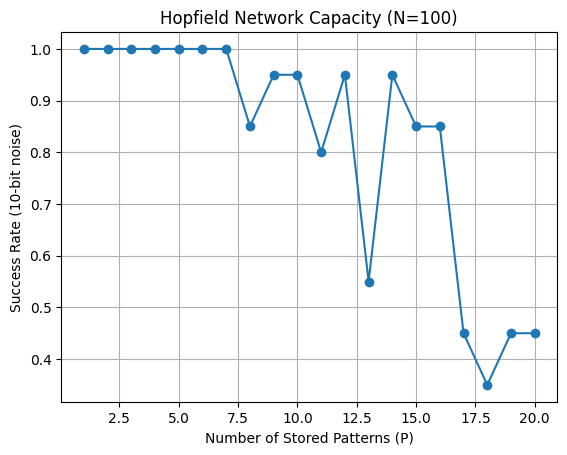

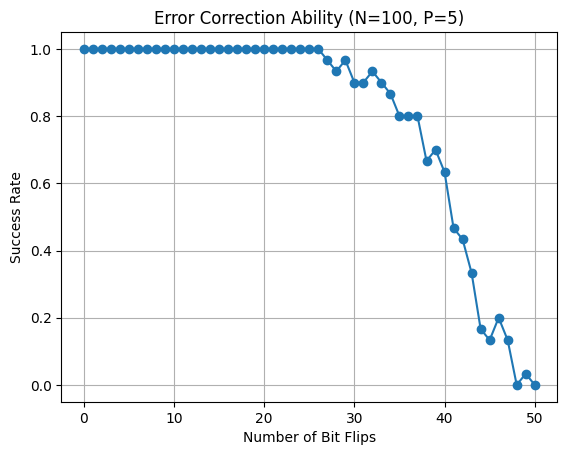

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

# -------------------------------
# Hopfield Network Implementation
# -------------------------------
class Hopfield:
    def __init__(self, N):
        self.N = N
        self.W = np.zeros((N, N))

    def train_hebbian(self, patterns):
        N = self.N
        P = len(patterns)
        self.W = np.zeros((N, N))
        for p in patterns:
            x = p.reshape(N, 1)
            self.W += x @ x.T
        np.fill_diagonal(self.W, 0)
        self.W /= N  # normalize weights

    def energy(self, state):
        return -0.5 * state.T @ self.W @ state

    def retrieve(self, init_state, max_steps=2000):
        state = init_state.copy()
        for _ in range(max_steps):
            i = np.random.randint(0, self.N)
            h = np.dot(self.W[i], state)
            state[i] = 1 if h >= 0 else -1
        return state


# -------------------------------
# Helper Functions
# -------------------------------
def random_pattern(N):
    return np.where(np.random.rand(N) > 0.5, 1, -1)


# -------------------------------
# Capacity Experiment (10-bit noise)
# -------------------------------
def test_capacity(N=100, max_P=20, noise=10, trials=20):
    results = []
    for P in range(1, max_P+1):
        success = 0
        patterns = np.array([random_pattern(N) for _ in range(P)])
        hop = Hopfield(N)
        hop.train_hebbian(patterns)

        for _ in range(trials):
            idx = np.random.randint(0, P)
            original = patterns[idx].copy()

            noisy = original.copy()
            flip_idx = np.random.choice(N, noise, replace=False)
            noisy[flip_idx] *= -1

            retrieved = hop.retrieve(noisy)
            if np.array_equal(retrieved, original):
                success += 1

        results.append((P, success / trials))

    return results


# -------------------------------
# Error Correction Test (vary flips)
# -------------------------------
def test_error_correction(N=100, P=5):
    patterns = np.array([random_pattern(N) for _ in range(P)])
    hop = Hopfield(N)
    hop.train_hebbian(patterns)

    original = patterns[0]
    flips_list = list(range(0, 51))
    results = []

    for flips in flips_list:
        success = 0
        for _ in range(30):
            noisy = original.copy()
            idxs = np.random.choice(N, flips, replace=False)
            noisy[idxs] *= -1
            retrieved = hop.retrieve(noisy)
            if np.array_equal(retrieved, original):
                success += 1
        results.append(success / 30)

    return flips_list, results


# -------------------------------
# Run & Plot Results
# -------------------------------
N = 100  # 10x10
capacity_results = test_capacity(N)

# Plot retrieval success vs number of patterns stored
Ps = [r[0] for r in capacity_results]
success = [r[1] for r in capacity_results]

plt.figure()
plt.plot(Ps, success, marker='o')
plt.xlabel('Number of Stored Patterns (P)')
plt.ylabel('Success Rate (10-bit noise)')
plt.title('Hopfield Network Capacity (N=100)')
plt.grid(True)
plt.show()

# Error correction with P = 5 (better correction)
flips_list, success_flips = test_error_correction(N, P=5)

plt.figure()
plt.plot(flips_list, success_flips, marker='o')
plt.xlabel('Number of Bit Flips')
plt.ylabel('Success Rate')
plt.title('Error Correction Ability (N=100, P=5)')
plt.grid(True)
plt.show()
